In [1]:
# Colab setup -- installs SoftMobility when running on Google Colab.
# Safe to run locally: it does nothing outside Colab.
try:
    import google.colab  # noqa: F401
    %pip install -q git+https://github.com/C0PEP0D/SoftMobility.git
except ImportError:
    pass

# Tutorial 13. Rotating elastic filament 

A flexible filament is anchored at one end on a clamp offset by
$\delta_0$ from a rotation axis, and the clamp is forced to rotate
at angular rate $\zeta$ around that axis with a fixed tilt $\psi$
relative to it. Viscous drag drives the chain into a steady,
body-frame chiral shape that wraps onto the rotation axis as the
dimensionless rotation rate $\mathrm{Sp}^4$ increases. We reproduce
the first four panels of this canonical setup of Coq, du Roure,
Marthelot, Bartolo & Fermigier (2008, 2009) at
$\mathrm{Sp}^4 = 0.5, 5, 15, 35$, with offset
$\delta_0 / L = 0.05$.

**Why this is a clamped-anchor problem.** The body's six-component
lab pose is *prescribed* by the actuator, so the body's
six-component velocity
$\mathbf{v}_0 = [\mathbf{u}_0, \boldsymbol{\omega}_0]$
becomes an input of the soft mobility equation rather than an
output. The six-component reaction force the anchor exerts on
sphere 0, $\mathbf{f}_0 = [\mathbf{F}_0, \mathbf{T}_0]$, is the
corresponding new unknown. The mobility equation is partitioned
(Appendix C of the manuscript): the top six rows form a
$6\times 6$ linear system for $\mathbf{f}_0$ given $\mathbf{v}_0$;
the bottom $N_Q$ rows then yield the deformation rate
$\dot{\mathbf{Q}}$.

The library exposes this via
[`FlowBodyRollout.rollout_clamped_anchor`](../classes/solver.py),
which takes the actuator's lab-frame **position** and **velocity**
as two callables of $t$ plus the body's initial orientation, and
returns the trajectory of the deformation DOFs together with the
reaction $\mathbf{f}_0$ at every step. The body's Rodrigues vector
is integrated forward internally with the same Bortz/RK4 scheme as
the standard rollout, so it stays singularity-free for unbounded
rotations.

In [2]:
import jax.numpy as jnp
import numpy as np

import softmobility as sm
from softmobility.classes import figstyle

figstyle.apply()
FIGDIR = "figures"

np.set_printoptions(precision=3, suppress=True)

## 1. Filament geometry

We model the filament as $N=8$ beads of radius $a=1$ connected by
rigid bonds of length $2a$. Bending modulus $K_b=30$, fluid
viscosity $\mu=1$. Following Coq, du Roure, Marthelot, Bartolo &
Fermigier (2009), the slender-body transverse drag per unit length
is
$$
\mu_\perp = \frac{4\pi\mu}{\ln(L/a) + 1/2},
$$
and the Sperm number is 
$$
\mathrm{Sp} = \frac{L}{L_\omega}, \qquad
L_\omega = \left(\frac{K_b}{\mu_\perp\,\omega}\right)^{1/4},
$$
so $\mathrm{Sp}^4 = L^4\,\mu_\perp\,\omega / K_b$ and the
prescribed angular frequency is
$\omega = \mathrm{Sp}^4\,K_b / (L^4\,\mu_\perp)$, with
$L = (N-1)\,2a$. Tilt angle $\psi = 15^\circ$ from the rotation axis (Coq's experimental
value). Geometry and elasticity are held fixed across the four
$\mathrm{Sp}^4$ runs; only $\omega$ changes.

**Note.** Here, we use the conventional definition of the Sperm number. In Coq et al. (2008,2009), they use a different convention: $\mathrm{Sp}_{\rm Coq} = \mathrm{Sp}^4$)

In [3]:
N = 8
a = 1.0
mu = 1.0
K_b = 30.0
psi = 15 / 180 * np.pi                              # 15° tilt

L = (N - 1) * 2 * a
mu_perp = 4 * np.pi * mu / (np.log(L / a) + 0.5)    # Slender-body
tau_el = mu_perp * L ** 4 / K_b                     # elastic relaxation time
print(f"L = {L:.1f}, K_b = {K_b}, mu_perp = {mu_perp:.3f}, tau_el = {tau_el:.1f}")

fiber = sm.FlexibleFiber(
    n_beads=N, radius=a, bending_rigidity=K_b, mass=0.0, planar=False,
)
rollout = sm.FlowBodyRollout(
    soft_body=fiber, flow=sm.no_flow(),
    input_map={"gravity": sm.gravity_field(g=0.0)},
)
print(f"FlexibleFiber: Nspheres = {fiber.Nspheres}, Ndof = {fiber.Ndof}")

L = 14.0, K_b = 30.0, mu_perp = 4.003, tau_el = 5126.3
FlexibleFiber: Nspheres = 8, Ndof = 14


## 2 — Anchor pose and velocity

The clamp is mounted on a rotating arm offset from the spin axis by
$\delta_0 = 0.05\,L$, so its lab-frame trajectory is the circle
$\mathbf{r}_0(t) = (0,\,\delta_0 \cos\omega t,\,\delta_0 \sin\omega t)$.
The lab-frame angular velocity is the constant
$\boldsymbol{\omega}_{\rm lab} = \omega\,\mathbf{e}_1$, and the
translational velocity is the rigid-body
$\mathbf{u}_0(t) = \boldsymbol{\omega}\times\mathbf{r}_0(t)$.

The body's initial orientation tilts $\mathbf{E}_1$ by $\psi$ around
$\mathbf{e}_3$. 

The method `rollout_clamped_anchor` integrates the body's Rodrigues vector
forward via Bortz from the supplied $\boldsymbol{\omega}_0(t)$ 
(no singular axis-angle reconstruction is needed).

In [4]:
delta0 = 0.05 * L


def make_anchor_position_fn(omega):
    """Anchor orbits the lab x-axis at radius delta0 in the y-z plane."""

    def anchor_position_fn(t):
        return jnp.array([
            0.0,
            delta0 * jnp.cos(omega * t),
            delta0 * jnp.sin(omega * t),
        ])

    return anchor_position_fn


def make_anchor_velocity_fn(omega):
    """Six-component lab velocity of the orbiting anchor: u_lab = omega x r."""
    omega_lab = jnp.array([omega, 0.0, 0.0])

    def anchor_velocity_fn(t):
        u_lab = jnp.array([
            0.0,
            -delta0 * omega * jnp.sin(omega * t),
             delta0 * omega * jnp.cos(omega * t),
        ])
        return jnp.concatenate([u_lab, omega_lab])

    return anchor_velocity_fn


INIT_ORIENTATION = jnp.array([0.0, 0.0, psi])

## 3. Run one $\mathrm{Sp}$ to show the API

We integrate for $\sim 5\,\tau_{\rm el}$ so the deformation
$\mathbf{Q}$ reaches a body-frame steady state. The relaxation
timescale is set by the slowest elastic mode
$\tau_{\rm el} = \mu_\perp\,L^4 / K_b$ and is the same for all
$\mathrm{Sp}^4$ values; only the lab-frame rotation period
$2\pi/\omega$ changes.

The integrator step is $\Delta t = 0.2\,(2a)^4\mu/K_b$, four
times the conservative default of the existing `rollout` —
well within RK4 stability for the bending modes.

In [5]:
def integrate_to_steady_state(sp4, n_tau=5.0, dt_safety=0.2):
    omega = sp4 * K_b / (L ** 4 * mu_perp)
    dt = dt_safety * (2 * a) ** 4 * mu / K_b
    n_steps = int(round(n_tau * tau_el / dt))
    positions, orientations, dofs, f_0 = rollout.rollout_clamped_anchor(
        dt=dt,
        n_steps=n_steps,
        anchor_position_fn=make_anchor_position_fn(omega),
        anchor_velocity_fn=make_anchor_velocity_fn(omega),
        init_orientation=INIT_ORIENTATION,
        init_dofs=jnp.zeros(fiber.Ndof),
    )
    positions.block_until_ready()
    return omega, dt, n_steps, np.asarray(dofs), np.asarray(f_0)


omega, dt, n_steps, dofs_traj, f_0_traj = integrate_to_steady_state(5.0)
print(f"Sp**4 = 5:  omega = {omega:.3e}, dt = {dt:.4f}, n_steps = {n_steps}")
print(f"final max|Q|       = {np.max(np.abs(dofs_traj[-1])):.3e}")
print(f"final max|f_0|     = {np.max(np.abs(f_0_traj[-1])):.3e}")
Q_dot_end = (dofs_traj[-1] - dofs_traj[-2]) / dt
ratio = np.max(np.abs(Q_dot_end)) * tau_el
print(f"final max|Q_dot|*tau_el = {ratio:.3e}  (steady state if << 1)")

Sp**4 = 5:  omega = 9.754e-04, dt = 0.1067, n_steps = 240294
final max|Q|       = 2.267e-01
final max|f_0|     = 1.192e+00
final max|Q_dot|*tau_el = 0.000e+00  (steady state if << 1)


## 4. Lab-frame snapshots over one rotation period

At steady state the chain has a fixed body-frame shape
$\mathbf{Q}_\star$; in the lab frame this shape rotates rigidly
around $\mathbf{e}_x$, with the clamp orbiting at radius $\delta_0$.
The figure superimposes `n_phases` snapshots of the chain over
one rotation period as red lines (default 16; pass
`n_phases=12` etc. to coarsen), with grey shadow projections on
the three back panels of the bounding box and the rotation axis
as a dotted guide. The bounding box is forced cubic via
`figstyle.cubic_bounds` so the orthographic camera renders a
true isometric projection. Style matches `fig_3d_com.pdf` of
tutorial 11.

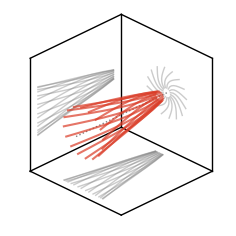

In [6]:
def _Rx(angle):
    c, s = np.cos(angle), np.sin(angle)
    return np.array([[1, 0, 0], [0, c, -s], [0, s, c]])


def _Rz(angle):
    c, s = np.cos(angle), np.sin(angle)
    return np.array([[c, -s, 0], [s, c, 0], [0, 0, 1]])


def body_frame_positions(dofs):
    """Body-frame bead positions (Nspheres, 3) for the given dofs."""
    out = np.zeros((fiber.Nspheres, 3))
    design_np = np.asarray(fiber.design_defaults)
    t_dummy = np.array([0.0])
    for i in range(fiber.Nspheres):
        out[i] = np.asarray(
            fiber.spheres[i].position(dofs, design_np, t_dummy)
        )
    return out


def make_figure(sp4, dofs_steady, omega, save_name, n_phases=16):
    body_pos = body_frame_positions(np.asarray(dofs_steady))
    period = 2 * np.pi / float(omega)
    times = np.linspace(0.0, period, n_phases, endpoint=False)
    R_z_psi = _Rz(psi)

    anchors_lab = np.stack(
        [np.array([0.0,
                   delta0 * np.cos(omega * t),
                   delta0 * np.sin(omega * t)])
         for t in times], axis=0,
    )
    chains_lab = np.stack(
        [a + body_pos @ (_Rx(omega * t) @ R_z_psi).T
         for t, a in zip(times, anchors_lab, strict=True)], axis=0,
    )
    bounds = figstyle.cubic_bounds(
        chains_lab[..., 0], chains_lab[..., 1], chains_lab[..., 2],
        pad=0.10 * float(L),
    )

    fig, ax = figstyle.figure_3d(size="third", aspect=1.0)
    figstyle.add_back_panels(ax, *bounds, color=figstyle.COLORS["black"], width=1.0)

    # Rotation axis (lab e_x) as a thin dotted guide.
    ax.plot(
        [bounds[0][0], bounds[0][1]], [0.0, 0.0], [0.0, 0.0],
        color=figstyle.COLORS["grey"], linewidth=1, linestyle=":",
    )

    # Per-phase shadows on the three back panels.
    for chain in chains_lab:
        figstyle.add_back_shadows(
            ax, chain[:, 0], chain[:, 1], chain[:, 2],
            bounds=bounds, color=figstyle.COLORS["grey"],
            width=1.0, opacity=0.4,
        )

    # Red chain centerlines (no markers).
    for chain in chains_lab:
        ax.plot(
            chain[:, 0], chain[:, 1], chain[:, 2],
            color=figstyle.COLORS["red"], linewidth=1.5, alpha=0.7,
        )

    ax.set_xlim(*bounds[0])
    ax.set_ylim(*bounds[1])
    ax.set_zlim(*bounds[2])

    figstyle.save(fig, save_name, figdir=FIGDIR)
    return fig


fig_demo = make_figure(5.0, dofs_traj[-1], omega, "fig_rotating_sp4_5")

## 5 — $\mathrm{Sp}$ scan: reproducing experimental results

Repeating the rollout for $\mathrm{Sp}^4 \in \{0.5, 5, 15, 35\}$
reproduces the first four panels of Coq, du Roure, Marthelot,
Bartolo & Fermigier (2008) Fig. 4 / Delmotte et al. (2015) Fig. 13
with the offset clamp $\delta_0/L = 0.05$:

* **$\mathrm{Sp}^4 = 0.5$**: chain essentially straight, tilted by
  $\psi$, traces a clean cone.
* **$\mathrm{Sp}^4 = 5$**: visible bending; the cone widens at the
  tip.
* **$\mathrm{Sp}^4 = 15$**: the chain noticeably wraps; the swept
  volume is a chiral leaf.
* **$\mathrm{Sp}^4 = 35$**: tighter wrapping onto the rotation
  axis.

Higher experimental $\mathrm{Sp}^4$ values (200, 1500, 3500) lie
outside the linearised-bending regime of `FlexibleFiber` (joint
angles $\gtrsim \pi/4$) and are not reproduced here.

Each figure is saved as
`figures/fig_rotating_sp4_{0p5|5|15|35}.pdf`.

Sp**4 =   0.5  omega = 9.754e-05  max|Q| = 3.373e-02  max|f_0| = 1.704e-01  max|Q_dot|*tau_el = 1.790e-04


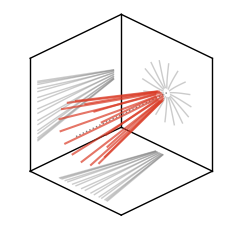

Sp**4 =     5  omega = 9.754e-04  max|Q| = 2.267e-01  max|f_0| = 1.192e+00  max|Q_dot|*tau_el = 0.000e+00


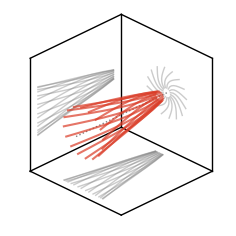

Sp**4 =    15  omega = 2.926e-03  max|Q| = 3.984e-01  max|f_0| = 1.848e+00  max|Q_dot|*tau_el = 0.000e+00


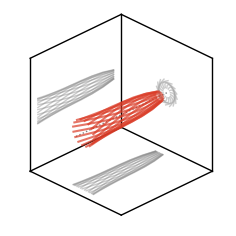

In [ ]:
from IPython.display import display

labels = {0.5: "0p5", 5.0: "5", 15.0: "15", 35.0: "35"}
for sp4 in (0.5, 5.0, 15.0, 35.0):
    omega, dt, n_steps, dofs_traj, f_0_traj = integrate_to_steady_state(sp4)
    Q_dot_end = (dofs_traj[-1] - dofs_traj[-2]) / dt
    print(
        f"Sp**4 = {sp4:>5g}  omega = {omega:.3e}  "
        f"max|Q| = {np.max(np.abs(dofs_traj[-1])):.3e}  "
        f"max|f_0| = {np.max(np.abs(f_0_traj[-1])):.3e}  "
        f"max|Q_dot|*tau_el = {np.max(np.abs(Q_dot_end))*tau_el:.3e}"
    )
    fig = make_figure(sp4, dofs_traj[-1], omega,
                       f"fig_rotating_sp4_{labels[sp4]}")
    display(fig)

## Notes

* **Anchor reaction force.** $\mathbf{f}_0$ is the force the
  external actuator exerts on sphere 0 to enforce the prescribed
  pose. Its component along the rotation axis is the propulsive
  thrust the filament generates against the actuator (Coq Fig. 5);
  here it grows monotonically with $\omega$ as expected. With the
  offset clamp ($\delta_0 = 0.05\,L$), $\mathbf{f}_0$ also carries
  the carriage's centripetal contribution, but at $O(\delta_0/L)$
  on top of an already-massless Stokes drag this barely shifts the
  printed magnitudes.
* **Linearised bending.** `FlexibleFiber` uses a small-angle
  expansion of the joint-angle bending energy, accurate for joint
  angles below ~π/4. This is why we cap the scan at
  $\mathrm{Sp}^4 = 35$ — above that, the chain wraps tightly and
  joint angles exceed the linearisation's regime of validity.
* **Frame conventions.** $\mathbf{v}_0$ and the input pose are
  supplied in the lab frame; $\mathbf{f}_0$ comes back in the
  body frame; the internal mobility tensors are body-frame too.
  The conversions happen inside `rollout_clamped_anchor`.
  Math: Appendix A 5 of Article 3.
* **Differentiability.** `rollout_clamped_anchor` is pure-functional
  and JAX-compatible, so the steady-state shape and propulsive
  thrust are differentiable with respect to design parameters
  (`bending_rigidity`, `radius`) and to the actuation
  (any closure parameter inside `make_anchor_velocity_fn`).

## References

N. Coq, O. Du Roure, J. Marthelot, D. Bartolo, and M. Fermigier, Rotational dynamics of a soft filament: Wrapping
transition and propulsive forces, *Phys. Fluids* **20** (2008).

N. Coq, O. d. Roure, M. Fermigier, and D. Bartolo, Helical beating of an actuated elastic filament, *J. Phys: Cond. Matter* **21**, 204109 (2009).

C. H. Wiggins, D. Riveline, A. Ott, and R. E. Goldstein, Trapping and wiggling: elastohydrodynamics of driven microfilaments, *Biophys. J.* **74**, 1043 (1998).